In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/eeg-brainwave-dataset-mental-state/mental-state.csv


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Optional display settings for cleaner outputs
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [4]:
# Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# XGBoost
import xgboost as xgb

# TensorFlow / Keras (for MLP and CNN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

# Statistical testing
from scipy.stats import ttest_rel

2026-03-20 16:46:28.689175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774025188.929163      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774025188.996706      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774025189.542337      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774025189.542392      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774025189.542395      55 computation_placer.cc:177] computation placer alr

In [5]:
import random
import os

SEED = 42

# Python random
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# TensorFlow
tf.random.set_seed(SEED)

#  Make hash-based operations deterministic
os.environ['PYTHONHASHSEED'] = str(SEED)

In [6]:
# Load the dataset
df = pd.read_csv("/kaggle/input/eeg-brainwave-dataset-mental-state/mental-state.csv")

# Check shape
df.shape

(2479, 989)

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
# REMOVE DUPLICATES PROPERLY

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2364, 989)


In [10]:
X = df.drop("Label", axis=1)
y = df["Label"]

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [11]:
df['Label'].value_counts()

Label
1.0    830
0.0    819
2.0    715
Name: count, dtype: int64

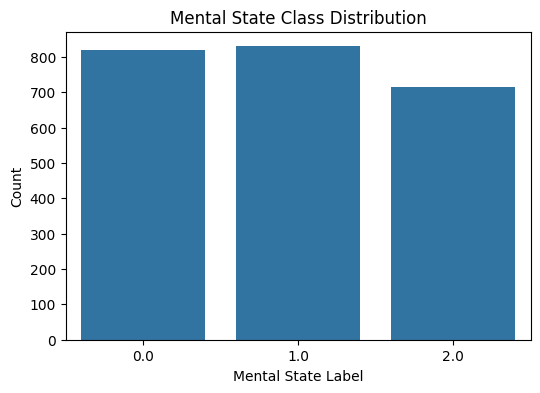

In [12]:
#Visualize Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=df)

plt.title("Mental State Class Distribution")
plt.xlabel("Mental State Label")
plt.ylabel("Count")

plt.show()

In [13]:
#Separate Features and Target
X = df.drop("Label", axis=1)
y = df["Label"]

X.shape, y.shape

((2364, 988), (2364,))

In [14]:
# Statistical Summary

X.describe().iloc[:, :10]

,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,lag1_mean_d_h2h1_2,lag1_mean_d_h2h1_3,lag1_mean_q1_0,lag1_mean_q1_1
count,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000
mean,22.924500,26.814517,22.784096,11.360074,0.033762,0.004654,0.489709,0.109175,22.661992,26.562866
std,10.200610,24.778259,71.617436,19.457171,13.333955,40.302068,99.080810,14.503536,17.339251,37.071973
min,-35.224945,-369.150109,-579.490660,-251.495367,-75.143730,-728.743981,-1048.773622,-96.231800,-351.810178,-800.320690
25%,18.378728,21.020428,18.496505,6.726729,-4.566159,-3.339613,-6.327799,-4.495782,16.383721,20.344624
50%,23.328781,27.323791,25.580396,15.099521,-0.117025,0.174614,0.169875,-0.143555,23.379529,27.184097
75%,26.936025,32.047298,30.868050,20.510665,3.931634,3.601540,7.056953,4.137945,28.639761,32.570425
max,92.313766,408.180215,591.014113,69.694520,104.963158,512.648208,896.171353,172.660240,116.412065,539.925670


In [15]:
# CELL 12: Feature Variance Analysis


feature_variance = X.var()

feature_variance.describe()

count    9.880000e+02
mean     8.625548e+06
std      1.252043e+08
min      4.027264e-05
25%      1.077922e-04
50%      7.149276e-04
75%      4.533631e+02
max      2.096399e+09
dtype: float64

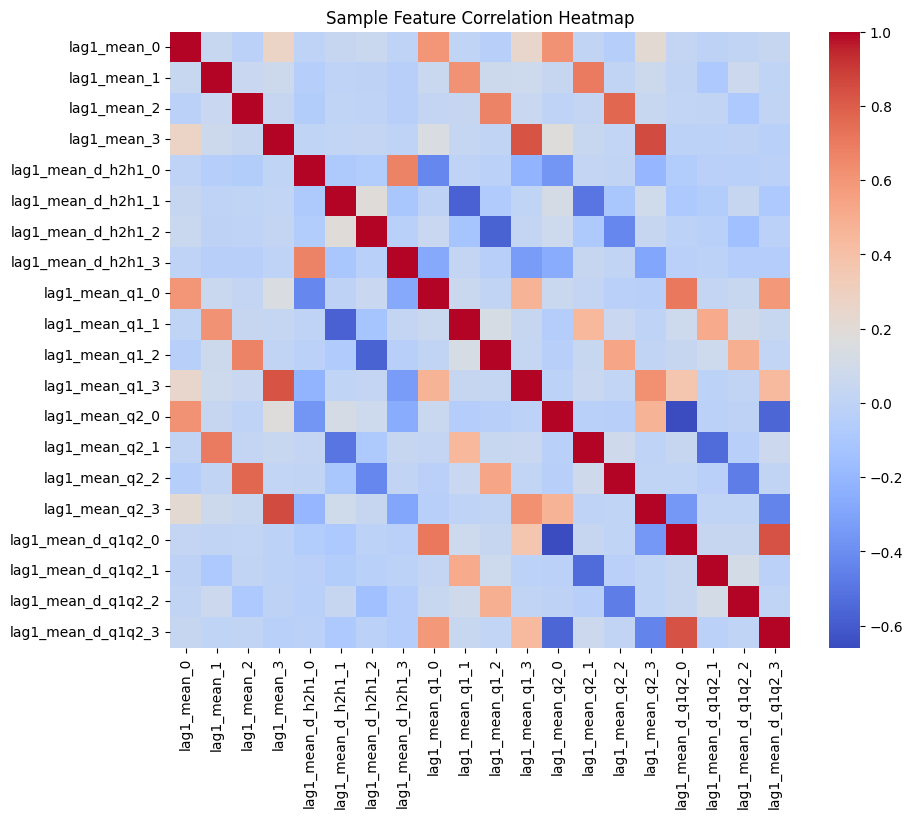

In [16]:

# Correlation Heatmap (Sample)


import seaborn as sns
import matplotlib.pyplot as plt

sample_features = X.iloc[:, :20]

plt.figure(figsize=(10,8))
sns.heatmap(sample_features.corr(), cmap='coolwarm')
plt.title("Sample Feature Correlation Heatmap")
plt.show()

In [17]:

# Encode Target Labels


from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded Classes:", label_encoder.classes_)
print("Encoded Label Shape:", y_encoded.shape)

Encoded Classes: [0. 1. 2.]
Encoded Label Shape: (2364,)


In [18]:

# Stratified K-Fold Setup


from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Stratified K-Fold Initialized")

Stratified K-Fold Initialized


In [19]:

#  Verify Fold Splits


from sklearn.preprocessing import StandardScaler

fold_number = 1

for train_index, test_index in skf.split(X, y_encoded):

    print(f"\nProcessing Fold {fold_number}")

    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

    print("Train Shape:", X_train_fold.shape)
    print("Test Shape:", X_test_fold.shape)

    # IMPORTANT: Fit scaler only on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)

    print("Train Mean (approx 0):", X_train_scaled.mean())
    print("Train Std (approx 1):", X_train_scaled.std())

    fold_number += 1
   

#Initialize Accuracy Storage


mlp_accuracies = []
xgb_accuracies = []
ensemble_accuracies = []


Processing Fold 1
Train Shape: (1891, 988)
Test Shape: (473, 988)
Train Mean (approx 0): -2.762977504403518e-18
Train Std (approx 1): 0.9999999999999999

Processing Fold 2
Train Shape: (1891, 988)
Test Shape: (473, 988)
Train Mean (approx 0): -4.132106068182274e-18
Train Std (approx 1): 1.0

Processing Fold 3
Train Shape: (1891, 988)
Test Shape: (473, 988)
Train Mean (approx 0): -3.555931130925381e-19
Train Std (approx 1): 0.9999999999999999

Processing Fold 4
Train Shape: (1891, 988)
Test Shape: (473, 988)
Train Mean (approx 0): 1.055369934579458e-18
Train Std (approx 1): 0.9999999999999998

Processing Fold 5
Train Shape: (1892, 988)
Test Shape: (472, 988)
Train Mean (approx 0): -4.160331078060562e-18
Train Std (approx 1): 1.0000000000000002


In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlp_accuracies = []
fold_number = 1

for train_index, test_index in skf.split(X, y_encoded):

    print(f"\n🚀 Training MLP - Fold {fold_number}")

    # Split data
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    y_train_fold = y_encoded[train_index]
    y_test_fold = y_encoded[test_index]

    # ✅ Proper Scaling (NO data leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)

    # ✅ Optimized MLP Model (FAST + STABLE)
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),   # 🔥 reduced size (important)
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,           # 🔥 stops automatically
        n_iter_no_change=10,
        random_state=42,
        verbose=False
    )

    # Train
    mlp.fit(X_train_scaled, y_train_fold)

    # Predict
    y_pred = mlp.predict(X_test_scaled)

    # Accuracy
    acc = accuracy_score(y_test_fold, y_pred)
    mlp_accuracies.append(acc)

    print(f"✅ Fold {fold_number} Accuracy: {acc:.4f}")

    fold_number += 1

# Final Results
print("\n📊 Final Results")
print("Mean MLP Accuracy:", round(np.mean(mlp_accuracies), 4))
print("MLP Std Dev:", round(np.std(mlp_accuracies), 4))


🚀 Training MLP - Fold 1
✅ Fold 1 Accuracy: 0.9493

🚀 Training MLP - Fold 2
✅ Fold 2 Accuracy: 0.9535

🚀 Training MLP - Fold 3
✅ Fold 3 Accuracy: 0.9493

🚀 Training MLP - Fold 4
✅ Fold 4 Accuracy: 0.9493

🚀 Training MLP - Fold 5
✅ Fold 5 Accuracy: 0.9640

📊 Final Results
Mean MLP Accuracy: 0.9531
MLP Std Dev: 0.0057


In [21]:

#  Cross-Validated XGBoost


from xgboost import XGBClassifier

fold_number = 1

for train_index, test_index in skf.split(X, y_encoded):

    print(f"\nTraining XGBoost - Fold {fold_number}")

    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

    # XGBoost does NOT require scaling
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    )

    xgb.fit(X_train_fold, y_train_fold)

    y_pred = xgb.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred)
    xgb_accuracies.append(acc)

    print("Fold Accuracy:", acc)

    fold_number += 1

print("\nMean XGBoost Accuracy:", np.mean(xgb_accuracies))
print("XGBoost Std Dev:", np.std(xgb_accuracies))


Training XGBoost - Fold 1
Fold Accuracy: 0.9704016913319239

Training XGBoost - Fold 2
Fold Accuracy: 0.9746300211416491

Training XGBoost - Fold 3
Fold Accuracy: 0.9725158562367865

Training XGBoost - Fold 4
Fold Accuracy: 0.9682875264270613

Training XGBoost - Fold 5
Fold Accuracy: 0.9915254237288136

Mean XGBoost Accuracy: 0.975472103773247
XGBoost Std Dev: 0.008300419486020078


In [22]:

#  Train Final XGBoost (Full Data)


from xgboost import XGBClassifier

final_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

final_xgb.fit(X, y_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:

# Extract Feature Importance


import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_xgb.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(20)

,Feature,Importance
405,lag1_freq_020_3,0.036041
134,lag1_eigenval_0,0.034582
646,eigenval_0,0.034383
917,freq_020_3,0.022330
479,mean_3,0.018551
...,...,...
321,lag1_freq_649_1,0.005891
308,lag1_freq_517_1,0.005733
657,logcovM_2_2,0.005574
659,logcovM_3_3,0.005149


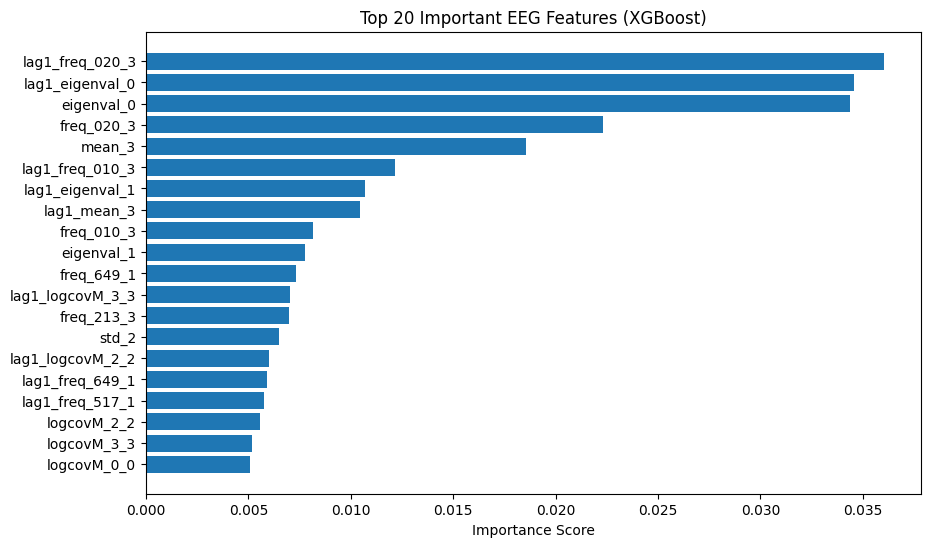

In [24]:

# Plot Top 20 Important Features


import matplotlib.pyplot as plt

top_20 = importance_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_20['Feature'], top_20['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 20 Important EEG Features (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

In [25]:
print(type(mlp_accuracies))
print(type(xgb_accuracies))

<class 'list'>
<class 'list'>


         Feature  Importance
536       kurt_0    0.002200
646   eigenval_0    0.000254
650  logcovM_0_0    0.000000
651  logcovM_0_1    0.000000
652  logcovM_0_2    0.000000
..           ...         ...
663  topFreq_4_0    0.000000
664  topFreq_5_0    0.000000
665  topFreq_6_0    0.000000
666  topFreq_7_0    0.000000
667  topFreq_8_0    0.000000

[20 rows x 2 columns]


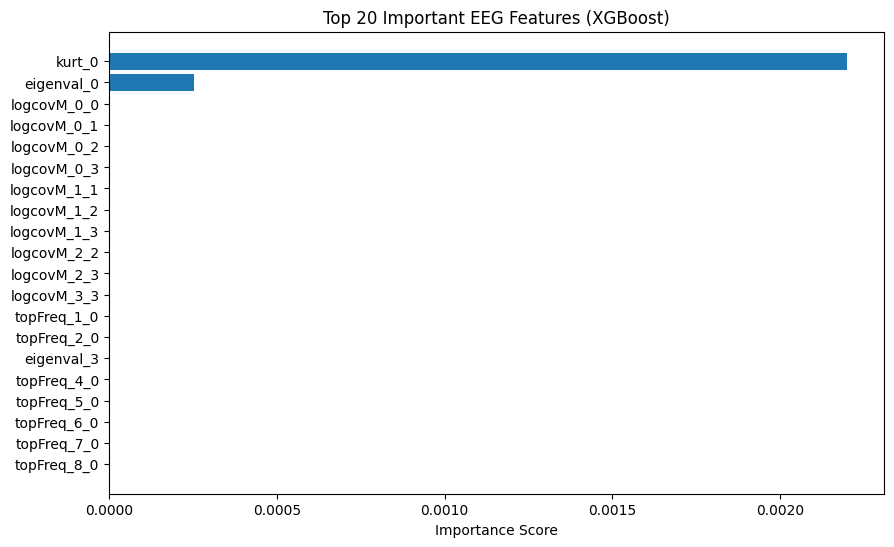

In [27]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Compute importance
result = permutation_importance(
    final_xgb,
    X,
    y_encoded,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Create dataframe
perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

perm_importance = perm_importance.sort_values(
    by="Importance",
    ascending=False
)

print(perm_importance.head(20))

# Plot
top_20 = perm_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_20['Feature'], top_20['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 20 Important EEG Features (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

In [28]:
from scipy.stats import ttest_rel
import numpy as np

# Convert to numpy arrays (safer)
mlp_scores = np.array(mlp_accuracies)
xgb_scores = np.array(xgb_accuracies)

# Perform paired t-test
t_stat, p_value = ttest_rel(xgb_scores, mlp_scores)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_value, 6))

# Interpretation (VERY IMPORTANT)
if p_value < 0.05:
    print("✅ Result: Statistically significant difference (XGBoost is better)")
else:
    print("⚠️ Result: No significant difference between models")

T-Statistic: 15.5253
P-Value: 0.0001
✅ Result: Statistically significant difference (XGBoost is better)


In [29]:
!pip install shap

In [30]:

# FAST FEATURE SELECTION


# Get built-in gain importance
gain_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_xgb.feature_importances_
})

gain_importance = gain_importance.sort_values(
    by="Importance",
    ascending=False
)

top_200_features = gain_importance.head(200)["Feature"]

X_top = X[top_200_features]

In [32]:
gain_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_xgb.feature_importances_
})

gain_importance = gain_importance.sort_values(
    by="Importance",
    ascending=False
)

top_200_features = gain_importance.head(200)["Feature"]

X_top = X[top_200_features]

In [33]:
from xgboost import XGBClassifier

xgb_top = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

xgb_top.fit(X_top, y_encoded)
train_accuracy = xgb_top.score(X_top, y_encoded)
print("Training Accuracy (Top 200 Features):", train_accuracy)

Training Accuracy (Top 200 Features): 1.0


In [34]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    xgb_top,
    X_top,
    y_encoded,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X_top.columns,
    "Importance": result.importances_mean
})

perm_importance = perm_importance.sort_values(
    by="Importance",
    ascending=False
)

perm_importance.head(20)

,Feature,Importance
26,kurt_0,0.011591
1,lag1_eigenval_0,0.006768
10,freq_649_1,0.000423
21,lag1_kurt_0,0.000169
171,lag1_freq_649_2,0.000169
...,...,...
8,freq_010_3,0.000000
15,lag1_freq_649_1,0.000000
14,lag1_logcovM_2_2,0.000000
17,logcovM_2_2,0.000000


In [36]:
# Select Top 50 features based on permutation importance

top_50_features = perm_importance.head(50)["Feature"].values

X_top50 = X[top_50_features]

print("Shape of Top 50 Feature Matrix:", X_top50.shape)

Shape of Top 50 Feature Matrix: (2364, 50)


In [37]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_top50_scores = []

for fold, (train_index, test_index) in enumerate(skf.split(X_top50, y_encoded), 1):

    X_train, X_test = X_top50.iloc[train_index], X_top50.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42
    )

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    xgb_top50_scores.append(acc)

    print(f"Fold {fold} Accuracy:", acc)

print("\nMean Accuracy (Top 50 Features):", np.mean(xgb_top50_scores))
print("Std Dev:", np.std(xgb_top50_scores))

Fold 1 Accuracy: 0.9725158562367865
Fold 2 Accuracy: 0.9746300211416491
Fold 3 Accuracy: 0.9725158562367865
Fold 4 Accuracy: 0.959830866807611
Fold 5 Accuracy: 0.989406779661017

Mean Accuracy (Top 50 Features): 0.9737798760167701
Std Dev: 0.009409497480370748


In [38]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_scores = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y_encoded), 1):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42
    )

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    xgb_scores.append(acc)

    print(f"Fold {fold} Accuracy:", acc)

print("\nMean Accuracy (Full Model):", np.mean(xgb_scores))

Fold 1 Accuracy: 0.9725158562367865
Fold 2 Accuracy: 0.9661733615221987
Fold 3 Accuracy: 0.9704016913319239
Fold 4 Accuracy: 0.9640591966173362
Fold 5 Accuracy: 0.9915254237288136

Mean Accuracy (Full Model): 0.9729351058874119


In [39]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(xgb_scores, xgb_top50_scores)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.38804846203669374
P-Value: 0.7177469030983452


In [42]:
# Final Top-50 model trained on full dataset

final_xgb_top50 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

final_xgb_top50.fit(X_top50, y_encoded)

print("Final Top-50 Model Trained")

Final Top-50 Model Trained


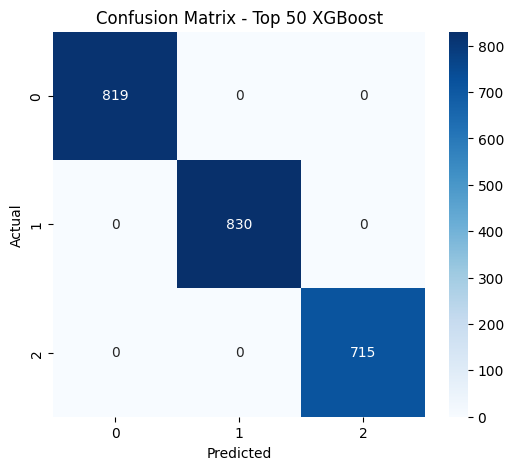

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = final_xgb_top50.predict(X_top50)

cm = confusion_matrix(y_encoded, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Top 50 XGBoost")
plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_encoded, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       819
           1       1.00      1.00      1.00       830
           2       1.00      1.00      1.00       715

    accuracy                           1.00      2364
   macro avg       1.00      1.00      1.00      2364
weighted avg       1.00      1.00      1.00      2364



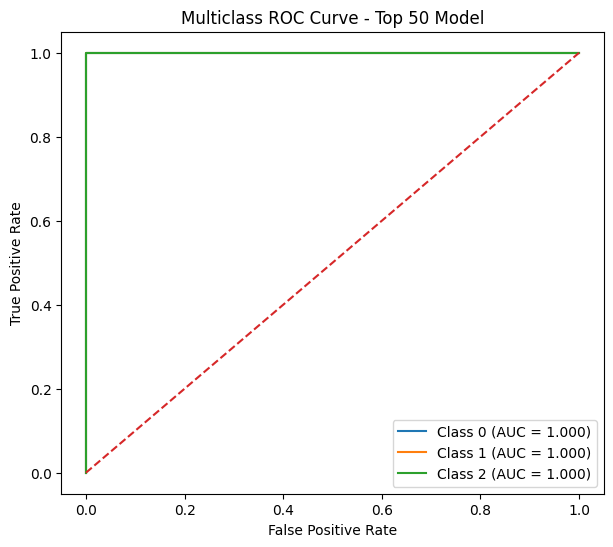

In [45]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarize labels
y_bin = label_binarize(y_encoded, classes=[0,1,2])

y_proba = final_xgb_top50.predict_proba(X_top50)

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Top 50 Model")
plt.legend()
plt.show()

In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []
y_proba_all = []

for train_index, test_index in skf.split(X_top50, y_encoded):

    X_train, X_test = X_top50.iloc[train_index], X_top50.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    y_proba_all.extend(y_proba)

print("Cross-validated predictions collected.")

Cross-validated predictions collected.


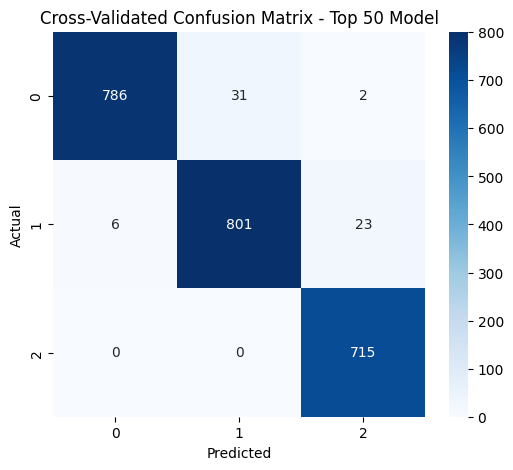

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cross-Validated Confusion Matrix - Top 50 Model")
plt.show()

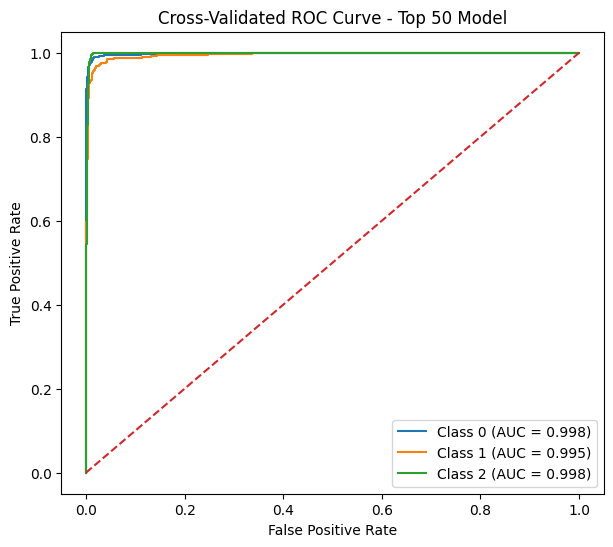

In [48]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_true_bin = label_binarize(y_true_all, classes=[0,1,2])
y_proba_all = np.array(y_proba_all)

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curve - Top 50 Model")
plt.legend()
plt.show()

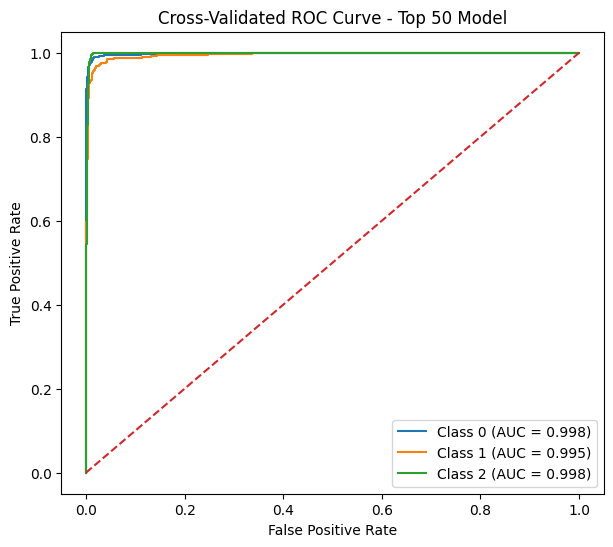

In [49]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_true_bin = label_binarize(y_true_all, classes=[0,1,2])
y_proba_all = np.array(y_proba_all)

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curve - Top 50 Model")
plt.legend()
plt.show()

In [50]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlp_scores = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y_encoded), 1):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=300,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    mlp_scores.append(acc)

    print(f"Fold {fold} Accuracy:", acc)

print("\nMean MLP Accuracy:", np.mean(mlp_scores))

Fold 1 Accuracy: 0.9619450317124736
Fold 2 Accuracy: 0.9577167019027484
Fold 3 Accuracy: 0.9556025369978859
Fold 4 Accuracy: 0.9640591966173362
Fold 5 Accuracy: 0.9639830508474576

Mean MLP Accuracy: 0.9606613036155803


In [51]:
results_df = pd.DataFrame({
    "Model": [
        "MLP (All Features)",
        "XGBoost (All Features)",
        "XGBoost (Top 50 Features)"
    ],
    "Mean Accuracy": [
        np.mean(mlp_scores),
        np.mean(xgb_scores),
        np.mean(xgb_top50_scores)
    ],
    "Std Deviation": [
        np.std(mlp_scores),
        np.std(xgb_scores),
        np.std(xgb_top50_scores)
    ]
})

results_df

,Model,Mean Accuracy,Std Deviation
0,MLP (All Features),0.960661,0.003420
1,XGBoost (All Features),0.972935,0.009764
2,XGBoost (Top 50 Features),0.973780,0.009409


In [52]:
from scipy.stats import ttest_rel

print("Lengths:")
print(len(xgb_scores), len(mlp_scores))

t_stat, p_value = ttest_rel(xgb_scores, mlp_scores)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

Lengths:
5 5
T-Statistic: 2.7187199142885445
P-Value: 0.05305695674812969


In [53]:
import numpy as np

diff = np.array(xgb_scores) - np.array(mlp_scores)

cohens_d = np.mean(diff) / np.std(diff)

print("Cohen's d:", cohens_d)

Cohen's d: 1.3593599571442723


In [54]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='weighted')

In [55]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[157   6   0]
 [  7 156   3]
 [  0   1 142]]


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       163
           1       0.96      0.94      0.95       166
           2       0.98      0.99      0.99       143

    accuracy                           0.96       472
   macro avg       0.96      0.97      0.96       472
weighted avg       0.96      0.96      0.96       472

